In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('cleaned1.csv')
data.head()

,Area in Sqrt,No.of Bhk,Location,price_rupees,price_per_sqft,area_per_bhk
0,3720,4,Sector 107,39000000,10483.870968,930.000000
1,1625,3,Sector 50,11500000,7076.923077,541.666667
2,1325,3,Sector 120,6000000,4528.301887,441.666667
3,650,1,Sector 73,1900000,2923.076923,650.000000
4,950,2,other,2599000,2735.789474,475.000000


In [5]:
Q1 = data['price_per_sqft'].quantile(0.25)
Q3 = data['price_per_sqft'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[(data['price_per_sqft'] >= lower) &
        (data['price_per_sqft'] <= upper)]

In [6]:
data['area_per_bhk'] = data['Area in Sqrt'] / data['No.of Bhk']

data = data[
    (data['area_per_bhk'] >= 200) &
    (data['area_per_bhk'] <= 1500)
]

In [8]:
data.describe()

,Area in Sqrt,No.of Bhk,price_rupees,price_per_sqft,area_per_bhk
count,4255.000000,4255.000000,4.255000e+03,4255.000000,4255.000000
mean,1927.489542,2.858049,1.534004e+07,6808.455642,637.953284
std,1273.322250,1.061160,1.561849e+07,3338.434735,212.092235
min,434.000000,1.000000,1.100000e+06,1406.752412,230.000000
25%,1050.000000,2.000000,3.929500e+06,3463.768116,483.333333
50%,1500.000000,3.000000,1.050000e+07,6534.090909,576.666667
75%,2500.000000,3.000000,2.110000e+07,9085.247778,750.400000
max,15000.000000,10.000000,1.685000e+08,19081.600993,1500.000000


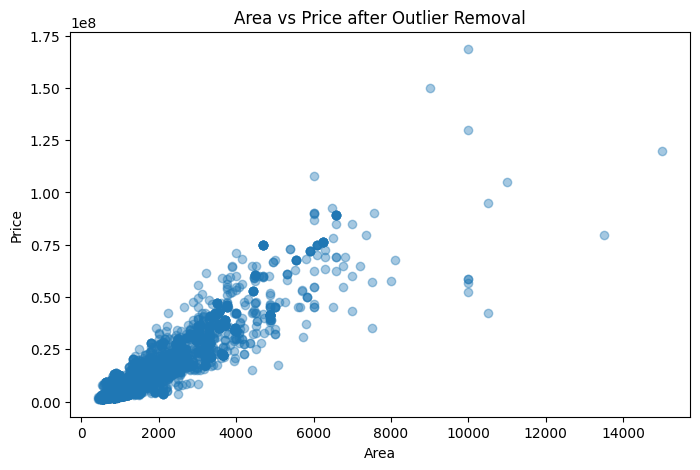

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(data['Area in Sqrt'], data['price_rupees'], alpha=0.4)
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price after Outlier Removal')
plt.show()

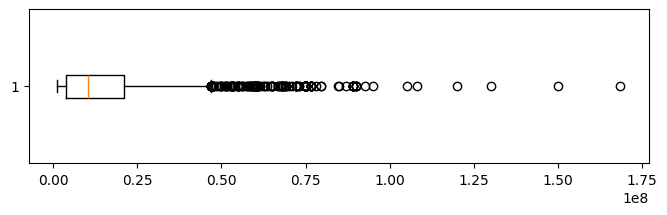

In [13]:
plt.figure(figsize=(8,2))
plt.boxplot(data['price_rupees'], vert=False)
plt.show()

In [14]:
data.to_csv('cleaned2.csv',index=False)